In [1]:
import cmocean
import numpy as np 
import xarray as xr
import pandas as pd 
import seaborn as sns
import cartopy.crs as ccrs
import statsmodels.api as sm
import matplotlib.pyplot as plt
from IPython.display import HTML
from scipy.stats import linregress 
from nemo_cookbook import NEMODataTree 
from matplotlib.patches import Rectangle
from OceanDataStore import OceanDataCatalog 
from matplotlib.animation import FuncAnimation

C:\Users\TomAH\anaconda3\envs\new_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
## Heat budget details:
    # Box region: 25-35W, 52-58N
    # Model: 1/4 degree, monthly mean
    # Desnity of seawater: 1025 Kg/m3
    # Speciic heat capacity of seawater: 4000 J/Kg/K
    # Assume constant mixed layer temperature

In [3]:
plt.rcParams['axes.labelsize'] = 15
plt.rcParams['xtick.labelsize'] = 15
plt.rcParams['ytick.labelsize'] = 15
plt.rcParams['legend.fontsize'] = 13

In [3]:
# Open monthly means 

catalog = OceanDataCatalog(catalog_name="noc-model-stac")
catalog.search(collection='noc-npd-era5', standard_name='sea_surface_temperature')
ds1 = catalog.open_dataset(id=catalog.Items[3].id,
                          start_datetime='1990-01',
                          end_datetime='2024-12')
catalog.search(collection='noc-npd-era5', item_name='domain_cfg')
config = catalog.open_dataset(id=catalog.Items[1].id)

# Merge into a data tree
datasets = {"parent": {"domain": config, "gridT": ds1}}
dt_global = NEMODataTree.from_datasets(datasets = datasets)

# Clip to bounding box
bbox = (-35.0, -25.0, 52.0, 58.0)
dt_clipped = dt_global.clip_grid(grid="gridT", bbox=bbox)

# Add lat and lon as co-ordinates
dt = dt_clipped.add_geoindex(grid="gridT")


            * Item ID: noc-npd-era5/npd-eorca1-era5v1/gn/T1y
              Title: eORCA1 ERA5v1 NPD T1y Icechunk repository
              Description: Icechunk repository containing eORCA1 ERA5v1 NPD global ocean physics annual mean outputs defined at T-points.
              Platform: gn
              Start Date: 1976-01-01T00:00:00Z
              End Date: 2025-07-31T00:00:00Z
            

            * Item ID: noc-npd-era5/npd-eorca1-era5v1/gn/T1m
              Title: eORCA1 ERA5v1 NPD T1m Icechunk repository
              Description: Icechunk repository containing eORCA1 ERA5v1 NPD global ocean physics monthly mean outputs defined at T-points.
              Platform: gn
              Start Date: 1976-01-01T00:00:00Z
              End Date: 2025-07-31T00:00:00Z
            

            * Item ID: noc-npd-era5/npd-eorca025-era5v1/gn/T1y_3d
              Title: eORCA025 ERA5v1 NPD T1y_3d Icechunk repository
              Description: Icechunk repository containing eORCA025 ERA5v1 

In [2]:
dt

NameError: name 'dt' is not defined

In [6]:
dt['gridT']['T_MLD_Product'] = dt['gridT']['tos_con'] * dt['gridT']['somxl010']
H_ts = (dt.integral(grid='gridT', var='T_MLD_Product', dims=['i', 'j'])) * 1025 * 4000
H_ts_july = H_ts.where(H_ts['time_counter'].dt.month == 7, drop = True)
deltaH = H_ts_july.diff(dim='time_counter').compute()


In [19]:
Integrated_SST = dt.integral(grid = 'gridT', var = 'tos_con', dims = ['i', 'j'])

In [8]:
HC = H_ts_july.isel(time_counter = slice(1, None)).compute()

In [5]:
Q = (dt.integral(grid='gridT', var='hfds', dims=['i', 'j'])).isel(time_counter = slice(6, 414)) 

In [6]:
seconds_in_month = Q['time_counter'].dt.days_in_month * 24 * 60 * 60
Q_Jpermonth = Q * seconds_in_month

In [7]:
Integrated_Q = Q_Jpermonth.coarsen(time_counter=12).sum()


In [8]:
new_times = np.array([f'{y}-07-16T12:00:00.000000000' for y in range(1991, 2025)], dtype='datetime64[ns]')
Integrated_Q = Integrated_Q.assign_coords(time_counter=new_times)


In [24]:
deltaH.to_netcdf('deltaH_method4.nc')
Integrated_Q.to_netcdf('Q_method4.nc')
HC.to_netcdf('July_HC.nc')
Integrated_SST.to_netcdf('Integrated_SST_again.nc')

In [4]:
# Start from here 

HC = xr.open_dataset('July_HC.nc')['T_MLD_Product']
deltaH = xr.open_dataset('deltaH_method4.nc')['T_MLD_Product']
Q = xr.open_dataset('Q_method4.nc')['__xarray_dataarray_variable__']
MLD = xr.open_dataset('integrated_MLD.nc')['somxl010']
Integrated_SST = xr.open_dataset('Integrated_SST_again.nc')['tos_con']


In [5]:
new_times = np.array([f'{y}-07-16T12:00:00.000000000' for y in range(1991, 2025)], dtype='datetime64[ns]')

MLDjuly = MLD.where(MLD['time_counter'].dt.month == 7, drop = True)
MLDjuly = MLDjuly.isel(time_counter = slice(1, None))
MLDjuly = MLDjuly.assign_coords(time_counter=new_times)

SSTjuly = Integrated_SST.where(Integrated_SST['time_counter'].dt.month == 7, drop = True)
SSTjuly = SSTjuly.isel(time_counter = slice(1, None))
SSTjuly = SSTjuly.assign_coords(time_counter=new_times)

In [6]:
# Calculate advective term and ratios 

advection = deltaH - Q
magnitude_ratios = abs(Q) / abs(advection)
heatflux_contribution = Q / deltaH

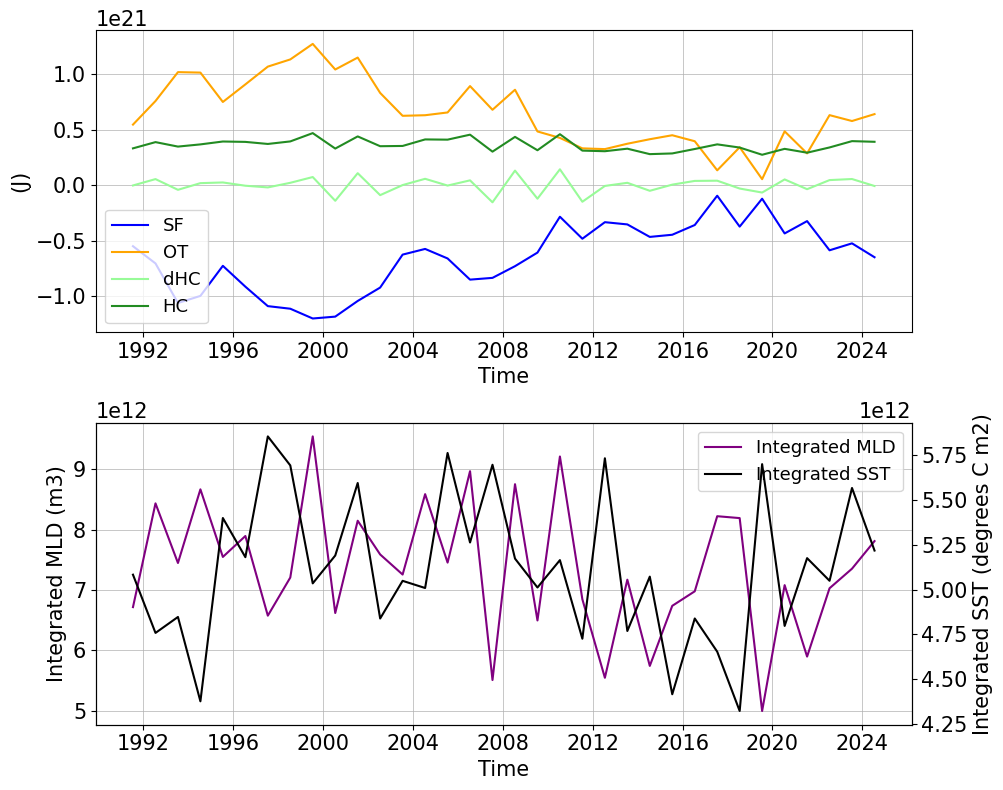

In [7]:
# Surface heat flux vs Advwection vs dH/dt 

time_numeric = np.arange(len(Q['time_counter']))

fig, ax = plt.subplots(2, 1, figsize = (10, 8))
ax1 = ax[0]
ax2 = ax[1]
ax3 = ax2.twinx()

l1 = ax1.plot(Q['time_counter'], Q, color = 'b', label = 'SF')
l2 = ax1.plot(advection['time_counter'], advection, color = 'orange', label = 'OT')
l3 = ax1.plot(deltaH['time_counter'], deltaH, color = '#98FB98', label = 'dHC')
l4 = ax1.plot(HC['time_counter'], HC, color = '#228B22', label = 'HC')
lines1 = l1 + l2 + l3+ l4
labels1 = [l.get_label() for l in lines1]
ax1.legend(lines1, labels1, loc = 'best')
ax1.set_xlabel('Time')
ax1.set_ylabel('(J)')
ax1.grid(True, which='both', linewidth=0.5)

l5 = ax2.plot(MLDjuly['time_counter'], MLDjuly, label = 'Integrated MLD', color = 'purple')
l6 = ax3.plot(SSTjuly['time_counter'], SSTjuly, label = 'Integrated SST', color = 'k')
lines2 = l5 + l6
labels2 = [l.get_label() for l in lines2]

ax2.legend(lines2, labels2, loc='best')
ax2.set_xlabel('Time')
ax2.set_ylabel('Integrated MLD (m3)')
ax3.set_ylabel('Integrated SST (degrees C m2)')
ax2.grid(True, which='both', linewidth=0.5)

plt.tight_layout()
plt.show()

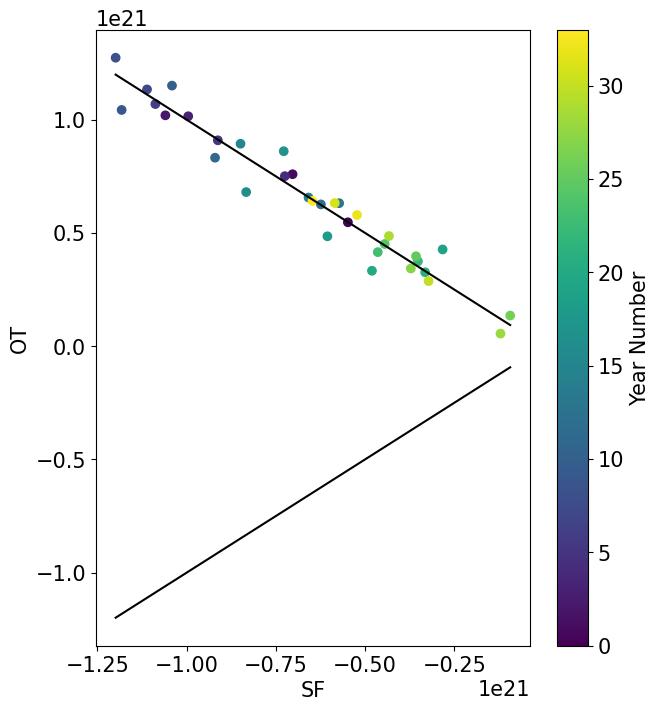

In [11]:
# Josey and Sinha Plot
progression = np.arange(len(Q.values))
fig, ax = plt.subplots(figsize = (7, 8))

plt.scatter(Q.values, advection.values, c = progression, cmap = 'viridis')
plt.xlabel('SF')
plt.ylabel('OT')

xmin = Q.min().item()
xmax = Q.max().item()
x = np.linspace(xmin, xmax, 100)
plt.plot(x, x, color = 'k')
plt.plot(x, -x, color = 'k')
plt.colorbar(ax = ax, label = ('Year Number'))

plt.show()

In [5]:
print(f'delta H standard deviation: {(deltaH.std(dim='time_counter')).values}')
print(f'Surface flux standard deviation: {(Q.std(dim='time_counter')).values}')
print(f'advection, entrainment, diffusion standard deviation: {(advection.std(dim='time_counter')).values}')

delta H standard deviation: 7.193176616204831e+19
Surface flux standard deviation: 2.9886253062089127e+20
advection, entrainment, diffusion standard deviation: 3.0221620694473776e+20
